In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("laptop.csv")

In [3]:
df.head()

,Unnamed: 0,Brand,Name,Price,Processor_Name,Processor_Brand,RAM_Expandable,RAM,RAM_TYPE,Ghz,Display_type,Display,GPU,GPU_Brand,SSD,HDD,Adapter,Battery_Life
0,0,HP,HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...,22990,MediaTek Octa-core,MediaTek,Not Expandable,4 GB,DDR4 RAM,2.0 Ghz Processor,LED,11.6,Integrated Graphics,MediaTek,64 GB SSD Storage,No HDD,45,Upto 12 Hrs Battery Life
1,1,Lenovo,Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....,36289,AMD Hexa-Core Ryzen 5,AMD,12 GB Expandable,8 GB,DDR4 RAM,4.0 Ghz Processor,LCD,15.6,Radeon,AMD,512 GB SSD Storage,No HDD,65,Upto 11 Hrs Battery Life
2,3,Dell,Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...,78500,Intel Core i5 (12th Gen),Intel,32 GB Expandable,16 GB,DDR5 RAM,3.3 Ghz Processor,LCD,15.6,"GeForce RTX 3050 GPU, 4 GB",NVIDIA,512 GB SSD Storage,No HDD,56,Upto 10 Hrs Battery Life
3,4,HP,HP 15s-fy5007TU (91R03PA) Laptop (15.6 Inch | ...,55490,Intel Core i5 (12th Gen),Intel,8 GB Expandable,8 GB,DDR4 RAM,4.2 Ghz Processor,LCD,15.6,Iris Xe,Intel,512 GB SSD Storage,No HDD,no,Upto 7.30 Hrs Battery Life
4,6,Infinix,Infinix Inbook Y2 Plus XL29 Laptop (15.6 Inch ...,21990,Intel Core i3 (11th Gen),Intel,Not Expandable,8 GB LP,LPDDR4X RAM,1.7 Ghz Processor,LCD,15.6,UHD,Intel,512 GB SSD Storage,No HDD,45,Upto 8 Hrs Battery Life


In [4]:
df.shape

(3976, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3976 entries, 0 to 3975
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       3976 non-null   int64 
 1   Brand            3976 non-null   object
 2   Name             3976 non-null   object
 3   Price            3976 non-null   int64 
 4   Processor_Name   3976 non-null   object
 5   Processor_Brand  3976 non-null   object
 6   RAM_Expandable   3976 non-null   object
 7   RAM              3976 non-null   object
 8   RAM_TYPE         3976 non-null   object
 9   Ghz              3976 non-null   object
 10  Display_type     3976 non-null   object
 11  Display          3976 non-null   object
 12  GPU              3968 non-null   object
 13  GPU_Brand        3972 non-null   object
 14  SSD              3976 non-null   object
 15  HDD              3976 non-null   object
 16  Adapter          3976 non-null   object
 17  Battery_Life     3558 non-null   

In [6]:
df.drop(columns=["Unnamed: 0"],inplace=True)

In [7]:
df.head()

,Brand,Name,Price,Processor_Name,Processor_Brand,RAM_Expandable,RAM,RAM_TYPE,Ghz,Display_type,Display,GPU,GPU_Brand,SSD,HDD,Adapter,Battery_Life
0,HP,HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...,22990,MediaTek Octa-core,MediaTek,Not Expandable,4 GB,DDR4 RAM,2.0 Ghz Processor,LED,11.6,Integrated Graphics,MediaTek,64 GB SSD Storage,No HDD,45,Upto 12 Hrs Battery Life
1,Lenovo,Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....,36289,AMD Hexa-Core Ryzen 5,AMD,12 GB Expandable,8 GB,DDR4 RAM,4.0 Ghz Processor,LCD,15.6,Radeon,AMD,512 GB SSD Storage,No HDD,65,Upto 11 Hrs Battery Life
2,Dell,Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...,78500,Intel Core i5 (12th Gen),Intel,32 GB Expandable,16 GB,DDR5 RAM,3.3 Ghz Processor,LCD,15.6,"GeForce RTX 3050 GPU, 4 GB",NVIDIA,512 GB SSD Storage,No HDD,56,Upto 10 Hrs Battery Life
3,HP,HP 15s-fy5007TU (91R03PA) Laptop (15.6 Inch | ...,55490,Intel Core i5 (12th Gen),Intel,8 GB Expandable,8 GB,DDR4 RAM,4.2 Ghz Processor,LCD,15.6,Iris Xe,Intel,512 GB SSD Storage,No HDD,no,Upto 7.30 Hrs Battery Life
4,Infinix,Infinix Inbook Y2 Plus XL29 Laptop (15.6 Inch ...,21990,Intel Core i3 (11th Gen),Intel,Not Expandable,8 GB LP,LPDDR4X RAM,1.7 Ghz Processor,LCD,15.6,UHD,Intel,512 GB SSD Storage,No HDD,45,Upto 8 Hrs Battery Life


In [8]:
df.isnull().sum()

Brand                0
Name                 0
Price                0
Processor_Name       0
Processor_Brand      0
RAM_Expandable       0
RAM                  0
RAM_TYPE             0
Ghz                  0
Display_type         0
Display              0
GPU                  8
GPU_Brand            4
SSD                  0
HDD                  0
Adapter              0
Battery_Life       418
dtype: int64

In [9]:
df['GPU'] = df['GPU'].fillna("Unknown")
df['GPU_Brand'] = df['GPU_Brand'].fillna("Unknown")
df['Battery_Life'] = df['Battery_Life'].fillna("Unknown")

In [10]:
df.isnull().sum()

Brand              0
Name               0
Price              0
Processor_Name     0
Processor_Brand    0
RAM_Expandable     0
RAM                0
RAM_TYPE           0
Ghz                0
Display_type       0
Display            0
GPU                0
GPU_Brand          0
SSD                0
HDD                0
Adapter            0
Battery_Life       0
dtype: int64

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 4


In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

C:\Users\miile\AppData\Local\Temp\ipykernel_2524\941010651.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Price"])


<Axes: xlabel='Price', ylabel='Density'>

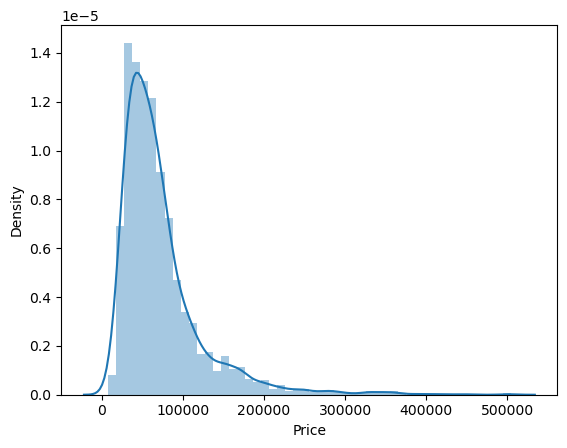

In [14]:
sns.distplot(df["Price"])

In [15]:
df["Brand"] = df["Brand"].str.strip()
print(df["Brand"].value_counts())

Brand
ASUS         989
Lenovo       809
HP           802
Dell         420
Acer         321
MSI          316
Samsung       61
Apple         49
Infinix       39
Microsoft     34
AVITA         23
Gigabyte      17
LG            15
Honor         14
iball         11
Xiaomi        10
Fujitsu        8
Zebronics      8
Wings          4
Realme         3
Coconics       3
Micromax       3
Colorful       3
Tecno          2
Smartron       2
Razer          1
Huawei         1
Lava           1
VAIO           1
Nokia          1
RDP            1
Name: count, dtype: int64


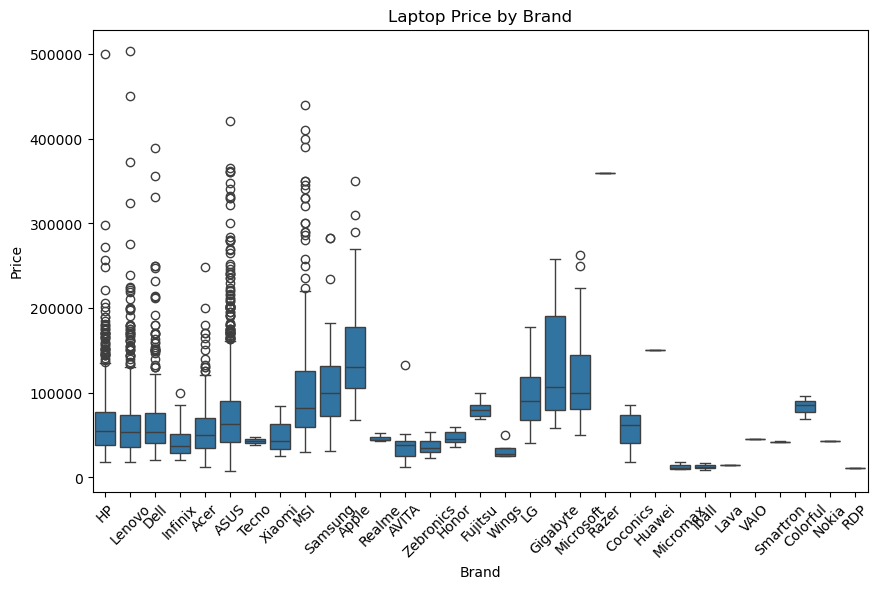

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Brand",
    y="Price"
)

plt.xticks(rotation=45)
plt.title("Laptop Price by Brand")
plt.show()

In [17]:
numeric_brand = df["Processor_Brand"].astype(str).str.fullmatch(
    r"\d+(\.\d+)?"
)

df.loc[numeric_brand, "Processor_Brand"] = (
    df.loc[numeric_brand, "Processor_Name"]
    .str.extract(r"^(Intel|AMD|Apple|MediaTek|Qualcomm|Microsoft)", expand=False)
)

In [18]:
df["Processor_Brand"] = df["Processor_Brand"].str.strip()

df["Processor_Brand"] = df["Processor_Brand"].replace({
    "Nvidia": "NVIDIA",
    "NIVIDIA": "NVIDIA"
})

df["Processor_Brand"] = df["Processor_Brand"].fillna("Unknown")

print(df["Processor_Brand"].value_counts())

Processor_Brand
Intel        3006
AMD           919
Unknown        21
Apple          20
MediaTek        4
Qualcomm        1
Microsoft       1
Name: count, dtype: int64


In [19]:
df["RAM_GB"] = pd.to_numeric(df["RAM"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
    .astype(float)
)

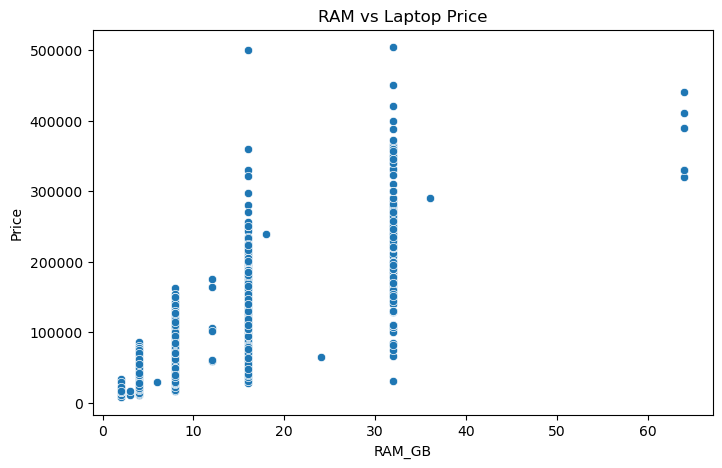

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="RAM_GB",
    y="Price"
)

plt.title("RAM vs Laptop Price")
plt.show()

In [21]:
df.drop(columns=["RAM"], inplace=True)

In [22]:
df.head()

,Brand,Name,Price,Processor_Name,Processor_Brand,RAM_Expandable,RAM_TYPE,Ghz,Display_type,Display,GPU,GPU_Brand,SSD,HDD,Adapter,Battery_Life,RAM_GB
0,HP,HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...,22990,MediaTek Octa-core,MediaTek,Not Expandable,DDR4 RAM,2.0 Ghz Processor,LED,11.6,Integrated Graphics,MediaTek,64 GB SSD Storage,No HDD,45,Upto 12 Hrs Battery Life,4.0
1,Lenovo,Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....,36289,AMD Hexa-Core Ryzen 5,AMD,12 GB Expandable,DDR4 RAM,4.0 Ghz Processor,LCD,15.6,Radeon,AMD,512 GB SSD Storage,No HDD,65,Upto 11 Hrs Battery Life,8.0
2,Dell,Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...,78500,Intel Core i5 (12th Gen),Intel,32 GB Expandable,DDR5 RAM,3.3 Ghz Processor,LCD,15.6,"GeForce RTX 3050 GPU, 4 GB",NVIDIA,512 GB SSD Storage,No HDD,56,Upto 10 Hrs Battery Life,16.0
3,HP,HP 15s-fy5007TU (91R03PA) Laptop (15.6 Inch | ...,55490,Intel Core i5 (12th Gen),Intel,8 GB Expandable,DDR4 RAM,4.2 Ghz Processor,LCD,15.6,Iris Xe,Intel,512 GB SSD Storage,No HDD,no,Upto 7.30 Hrs Battery Life,8.0
4,Infinix,Infinix Inbook Y2 Plus XL29 Laptop (15.6 Inch ...,21990,Intel Core i3 (11th Gen),Intel,Not Expandable,LPDDR4X RAM,1.7 Ghz Processor,LCD,15.6,UHD,Intel,512 GB SSD Storage,No HDD,45,Upto 8 Hrs Battery Life,8.0


In [23]:
df["RAM_TYPE"] = (df["RAM_TYPE"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["RAM_TYPE"] = df["RAM_TYPE"].replace({
    "nan": "Unknown",
    "RAM": "Unknown"
})

print(df["RAM_TYPE"].value_counts())

RAM_TYPE
DDR4 RAM       2817
DDR5 RAM        393
LPDDR5 RAM      241
LPDDR4X RAM     158
DDR3 RAM        156
LPDDR5X RAM      79
LPDDR3 RAM       51
Unknown          40
LPDDR4 RAM       36
DDR2 RAM          1
Name: count, dtype: int64


In [24]:
df["Ghz"] = pd.to_numeric(
    df["Ghz"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce"
)

In [25]:
df.loc[df["Ghz"] == 0, "Ghz"] = np.nan

In [26]:
df.head()

,Brand,Name,Price,Processor_Name,Processor_Brand,RAM_Expandable,RAM_TYPE,Ghz,Display_type,Display,GPU,GPU_Brand,SSD,HDD,Adapter,Battery_Life,RAM_GB
0,HP,HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...,22990,MediaTek Octa-core,MediaTek,Not Expandable,DDR4 RAM,2.0,LED,11.6,Integrated Graphics,MediaTek,64 GB SSD Storage,No HDD,45,Upto 12 Hrs Battery Life,4.0
1,Lenovo,Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....,36289,AMD Hexa-Core Ryzen 5,AMD,12 GB Expandable,DDR4 RAM,4.0,LCD,15.6,Radeon,AMD,512 GB SSD Storage,No HDD,65,Upto 11 Hrs Battery Life,8.0
2,Dell,Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...,78500,Intel Core i5 (12th Gen),Intel,32 GB Expandable,DDR5 RAM,3.3,LCD,15.6,"GeForce RTX 3050 GPU, 4 GB",NVIDIA,512 GB SSD Storage,No HDD,56,Upto 10 Hrs Battery Life,16.0
3,HP,HP 15s-fy5007TU (91R03PA) Laptop (15.6 Inch | ...,55490,Intel Core i5 (12th Gen),Intel,8 GB Expandable,DDR4 RAM,4.2,LCD,15.6,Iris Xe,Intel,512 GB SSD Storage,No HDD,no,Upto 7.30 Hrs Battery Life,8.0
4,Infinix,Infinix Inbook Y2 Plus XL29 Laptop (15.6 Inch ...,21990,Intel Core i3 (11th Gen),Intel,Not Expandable,LPDDR4X RAM,1.7,LCD,15.6,UHD,Intel,512 GB SSD Storage,No HDD,45,Upto 8 Hrs Battery Life,8.0


In [27]:
df["Display_inches"] = pd.to_numeric(
    df["Display"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce"
)

In [28]:
df.drop(columns=["Display"], inplace=True)

In [29]:
df["GPU_Brand"] = df["GPU_Brand"].fillna("Unknown")

df["GPU_Brand"] = df["GPU_Brand"].replace({
    "Nvidia": "NVIDIA",
    "NIVIDIA": "NVIDIA"
})

df["GPU_Brand"] = df["GPU_Brand"].str.strip()

In [30]:
df["GPU_VRAM_GB"] = pd.to_numeric(
    df["GPU"]
    .fillna("Unknown")
    .astype(str)
    .str.extract(
        r"(\d+(?:\.\d+)?)\s*GB",
        expand=False
    ),
    errors="coerce"
).fillna(0)

In [31]:
gpu = df["GPU"].fillna("Unknown").astype(str)

df["GPU_Type"] = np.where(
    gpu.str.contains(
        r"RTX|GTX|GeForce MX",
        case=False,
        regex=True
    ),
    "Dedicated",
    np.where(
        gpu.str.contains(
            r"GeForce|Radeon|Arc",
            case=False,
            regex=True
        ),
        "Dedicated/Unknown",
        "Integrated"
    )
)

In [32]:
df.drop(columns=["GPU"], inplace=True)

In [33]:
df.sample(10)

,Brand,Name,Price,Processor_Name,Processor_Brand,RAM_Expandable,RAM_TYPE,Ghz,Display_type,GPU_Brand,SSD,HDD,Adapter,Battery_Life,RAM_GB,Display_inches,GPU_VRAM_GB,GPU_Type
2906,Dell,Dell Inspiron 15 3576 (B566104WIN9) Laptop (15...,44990,Intel Core i5 (8th Gen),Intel,16 GB Expandable,DDR4 RAM,1.6,LED,Intel,NO SSD,1024 GB HDD Storage,45,45W Adapter,8.0,15.6,0.0,Integrated
672,ASUS,ASUS ROG Flow Z13 GZ301ZE-LD064WS Laptop (13.4...,181990,Intel Core i9 (12th Gen),Intel,Not Expandable,LPDDR5 RAM,2.5,LCD,NVIDIA,1024 GB SSD Storage,No HDD,100,Upto 8 Hrs Battery Life,16.0,13.4,4.0,Dedicated
184,HP,HP 14s-fy1003AU (6K7V7PA) Laptop (14 Inch | AM...,50568,AMD Hexa-Core Ryzen 5,AMD,Not Expandable,DDR4 RAM,4.0,LCD,AMD,512 GB SSD Storage,No HDD,65,Upto 12 Hrs Battery Life,16.0,14.0,0.0,Dedicated/Unknown
2497,ASUS,ASUS ROG Strix Scar 16 G634JZ-N4062WS Laptop (...,279990,Intel Core i9 (13th Gen),Intel,64 GB Expandable,DDR5 RAM,2.2,LCD,NVIDIA,1024 GB SSD Storage,No HDD,330,330W Adapter,32.0,16.0,12.0,Dedicated
2783,Dell,Dell XPS 13 Plus 9320 (D560073WIN9S) Laptop (1...,180403,Intel Core i7 (12th Gen),Intel,Not Expandable,LPDDR5 RAM,4.7,LCD,Intel,1024 GB SSD Storage,No HDD,65,65W Adapter,16.0,13.4,0.0,Integrated
464,Lenovo,Lenovo Ideapad Gaming 3 15IHU6 (82K101EEIN) La...,64499,Intel Core i5 (11th Gen),Intel,Not Expandable,DDR4 RAM,3.3,LCD,NVIDIA,512 GB SSD Storage,No HDD,65,Upto 4.5 Hrs Battery Life,8.0,15.6,4.0,Dedicated
228,HP,HP Victus 15-fa1132TX (8U6Z8PA) Laptop (15.6 I...,59490,Intel Core i5 (12th Gen),Intel,Not Expandable,DDR4 RAM,4.2,LCD,NVIDIA,512 GB SSD Storage,No HDD,no,Unknown,8.0,15.6,4.0,Dedicated
1979,Dell,Dell Inspiron 14 5406 (D560367WIN9S) Laptop (1...,78999,Intel Core i5 (11th Gen),Intel,Not Expandable,DDR4 RAM,2.4,LED,Intel,512 GB SSD Storage,No HDD,53,53W Adapter,8.0,14.0,0.0,Integrated
2114,Dell,Dell Inspiron 14 5406 (D560384WIN9S) Laptop (1...,63999,Intel Core i3 (11th Gen),Intel,16 GB Expandable,DDR4 RAM,3.0,LED,Intel,512 GB SSD Storage,No HDD,no,Upto 6 Hrs Battery Life,8.0,14.0,0.0,Integrated
142,Lenovo,Lenovo Ideapad Yoga 510 (80S700DRIH) Laptop (1...,40940,Intel Core i3 (6th Gen),Intel,Not Expandable,DDR4 RAM,2.0,LED,Intel,NO SSD,1024 GB HDD Storage,no,Unknown,4.0,14.0,0.0,Integrated


In [34]:
df["SSD_GB"] = pd.to_numeric(
    df["SSD"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce"
)

In [35]:
df.loc[
    df["SSD"].astype(str).str.contains("NO SSD", case=False, na=False),
    "SSD_GB"
] = 0

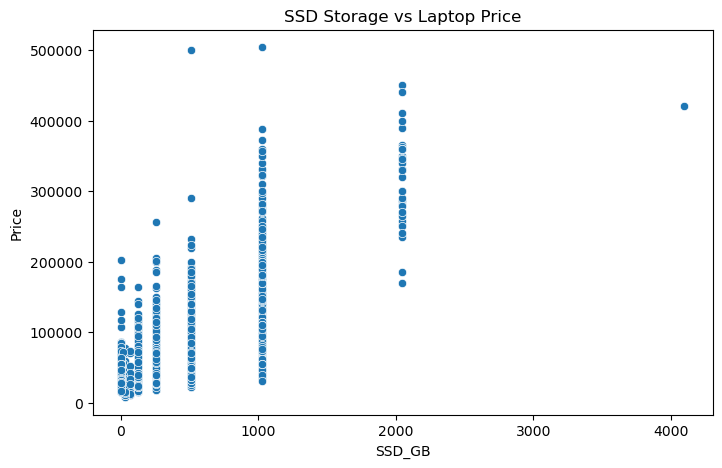

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="SSD_GB",
    y="Price"
)

plt.title("SSD Storage vs Laptop Price")
plt.show()

In [37]:
df.drop(columns=["SSD"], inplace=True)

In [38]:
df["HDD_GB"] = pd.to_numeric(
    df["HDD"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce"
)

In [39]:
df.loc[
    df["HDD"].astype(str).str.contains("No HDD", case=False, na=False),
    "HDD_GB"
] = 0

In [40]:
df.drop(columns=["HDD"], inplace=True)

In [41]:
df["Battery_Hours"] = pd.to_numeric(
    df["Battery_Life"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)\s*Hrs", expand=False),
    errors="coerce"
)

In [42]:
df.drop(columns=["Battery_Life"], inplace=True)

In [43]:
print(df.isnull().sum())

Brand                 0
Name                  0
Price                 0
Processor_Name        0
Processor_Brand       0
RAM_Expandable        0
RAM_TYPE              0
Ghz                 224
Display_type          0
GPU_Brand             0
Adapter               0
RAM_GB                0
Display_inches        1
GPU_VRAM_GB           0
GPU_Type              0
SSD_GB                0
HDD_GB                0
Battery_Hours      2475
dtype: int64


In [44]:
numeric_columns = [
    "Ghz",
    "Display_inches",
    "Battery_Hours"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [45]:
df.head()

,Brand,Name,Price,Processor_Name,Processor_Brand,RAM_Expandable,RAM_TYPE,Ghz,Display_type,GPU_Brand,Adapter,RAM_GB,Display_inches,GPU_VRAM_GB,GPU_Type,SSD_GB,HDD_GB,Battery_Hours
0,HP,HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...,22990,MediaTek Octa-core,MediaTek,Not Expandable,DDR4 RAM,2.0,LED,MediaTek,45,4.0,11.6,0.0,Integrated,64.0,0.0,12.0
1,Lenovo,Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....,36289,AMD Hexa-Core Ryzen 5,AMD,12 GB Expandable,DDR4 RAM,4.0,LCD,AMD,65,8.0,15.6,0.0,Dedicated/Unknown,512.0,0.0,11.0
2,Dell,Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...,78500,Intel Core i5 (12th Gen),Intel,32 GB Expandable,DDR5 RAM,3.3,LCD,NVIDIA,56,16.0,15.6,4.0,Dedicated,512.0,0.0,10.0
3,HP,HP 15s-fy5007TU (91R03PA) Laptop (15.6 Inch | ...,55490,Intel Core i5 (12th Gen),Intel,8 GB Expandable,DDR4 RAM,4.2,LCD,Intel,no,8.0,15.6,0.0,Integrated,512.0,0.0,7.3
4,Infinix,Infinix Inbook Y2 Plus XL29 Laptop (15.6 Inch ...,21990,Intel Core i3 (11th Gen),Intel,Not Expandable,LPDDR4X RAM,1.7,LCD,Intel,45,8.0,15.6,0.0,Integrated,512.0,0.0,8.0


In [46]:
print(df.columns.tolist())

['Brand', 'Name', 'Price', 'Processor_Name', 'Processor_Brand', 'RAM_Expandable', 'RAM_TYPE', 'Ghz', 'Display_type', 'GPU_Brand', 'Adapter', 'RAM_GB', 'Display_inches', 'GPU_VRAM_GB', 'GPU_Type', 'SSD_GB', 'HDD_GB', 'Battery_Hours']


In [47]:
import re

df["Processor_Family"] = (
    df["Processor_Name"]
    .astype(str)
    .str.extract(
        r"(Core\s+i9|Core\s+i7|Core\s+i5|Core\s+i3|Core\s+Ultra\s+[579]|Ryzen\s+[3579]|Celeron|Pentium|Athlon|Snapdragon|MediaTek|Apple)",
        flags=re.IGNORECASE,
        expand=False
    )
    .fillna("Other")
)

df[["Processor_Name", "Processor_Family"]].head(10)

,Processor_Name,Processor_Family
0,MediaTek Octa-core,MediaTek
1,AMD Hexa-Core Ryzen 5,Ryzen 5
2,Intel Core i5 (12th Gen),Core i5
3,Intel Core i5 (12th Gen),Core i5
4,Intel Core i3 (11th Gen),Core i3
5,Intel Core i5 (11th Gen) Processor,Core i5
6,AMD Hexa-Core Ryzen 5,Ryzen 5
7,Intel Core i5 (11th Gen),Core i5
8,Intel Core i3 (8th Gen),Core i3
9,Intel Core i5 (11th Gen),Core i5


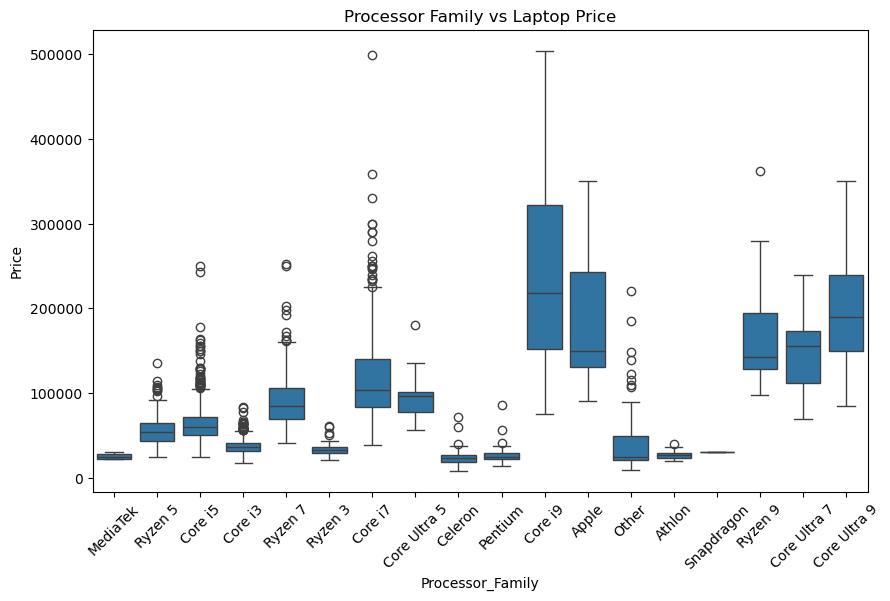

In [48]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Processor_Family",
    y="Price"
)

plt.xticks(rotation=45)
plt.title("Processor Family vs Laptop Price")
plt.show()

In [49]:
df["Processor_Family"].value_counts()

Processor_Family
Core i5         1285
Core i3          683
Core i7          646
Ryzen 5          372
Ryzen 7          267
Other            139
Ryzen 3          118
Celeron          112
Core i9           92
Pentium           58
Core Ultra 7      52
Ryzen 9           47
Athlon            35
Core Ultra 5      24
Apple             20
Core Ultra 9      17
MediaTek           4
Snapdragon         1
Name: count, dtype: int64

In [50]:
df["Processor_Generation"] = pd.to_numeric(
    df["Processor_Name"]
    .astype(str)
    .str.extract(
        r"(\d+)(?:st|nd|rd|th)?\s*Gen",
        expand=False
    ),
    errors="coerce"
)

df[["Processor_Name", "Processor_Generation"]].head(10)

,Processor_Name,Processor_Generation
0,MediaTek Octa-core,NaN
1,AMD Hexa-Core Ryzen 5,NaN
2,Intel Core i5 (12th Gen),12.0
3,Intel Core i5 (12th Gen),12.0
4,Intel Core i3 (11th Gen),11.0
5,Intel Core i5 (11th Gen) Processor,11.0
6,AMD Hexa-Core Ryzen 5,NaN
7,Intel Core i5 (11th Gen),11.0
8,Intel Core i3 (8th Gen),8.0
9,Intel Core i5 (11th Gen),11.0


In [51]:
df["Processor_Family"].value_counts()

Processor_Family
Core i5         1285
Core i3          683
Core i7          646
Ryzen 5          372
Ryzen 7          267
Other            139
Ryzen 3          118
Celeron          112
Core i9           92
Pentium           58
Core Ultra 7      52
Ryzen 9           47
Athlon            35
Core Ultra 5      24
Apple             20
Core Ultra 9      17
MediaTek           4
Snapdragon         1
Name: count, dtype: int64

In [52]:
df.head()

,Brand,Name,Price,Processor_Name,Processor_Brand,RAM_Expandable,RAM_TYPE,Ghz,Display_type,GPU_Brand,Adapter,RAM_GB,Display_inches,GPU_VRAM_GB,GPU_Type,SSD_GB,HDD_GB,Battery_Hours,Processor_Family,Processor_Generation
0,HP,HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...,22990,MediaTek Octa-core,MediaTek,Not Expandable,DDR4 RAM,2.0,LED,MediaTek,45,4.0,11.6,0.0,Integrated,64.0,0.0,12.0,MediaTek,NaN
1,Lenovo,Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....,36289,AMD Hexa-Core Ryzen 5,AMD,12 GB Expandable,DDR4 RAM,4.0,LCD,AMD,65,8.0,15.6,0.0,Dedicated/Unknown,512.0,0.0,11.0,Ryzen 5,NaN
2,Dell,Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...,78500,Intel Core i5 (12th Gen),Intel,32 GB Expandable,DDR5 RAM,3.3,LCD,NVIDIA,56,16.0,15.6,4.0,Dedicated,512.0,0.0,10.0,Core i5,12.0
3,HP,HP 15s-fy5007TU (91R03PA) Laptop (15.6 Inch | ...,55490,Intel Core i5 (12th Gen),Intel,8 GB Expandable,DDR4 RAM,4.2,LCD,Intel,no,8.0,15.6,0.0,Integrated,512.0,0.0,7.3,Core i5,12.0
4,Infinix,Infinix Inbook Y2 Plus XL29 Laptop (15.6 Inch ...,21990,Intel Core i3 (11th Gen),Intel,Not Expandable,LPDDR4X RAM,1.7,LCD,Intel,45,8.0,15.6,0.0,Integrated,512.0,0.0,8.0,Core i3,11.0


In [53]:
df.drop(columns=["Processor_Name"], inplace=True)

In [54]:
df.head()


,Brand,Name,Price,Processor_Brand,RAM_Expandable,RAM_TYPE,Ghz,Display_type,GPU_Brand,Adapter,RAM_GB,Display_inches,GPU_VRAM_GB,GPU_Type,SSD_GB,HDD_GB,Battery_Hours,Processor_Family,Processor_Generation
0,HP,HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...,22990,MediaTek,Not Expandable,DDR4 RAM,2.0,LED,MediaTek,45,4.0,11.6,0.0,Integrated,64.0,0.0,12.0,MediaTek,NaN
1,Lenovo,Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....,36289,AMD,12 GB Expandable,DDR4 RAM,4.0,LCD,AMD,65,8.0,15.6,0.0,Dedicated/Unknown,512.0,0.0,11.0,Ryzen 5,NaN
2,Dell,Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...,78500,Intel,32 GB Expandable,DDR5 RAM,3.3,LCD,NVIDIA,56,16.0,15.6,4.0,Dedicated,512.0,0.0,10.0,Core i5,12.0
3,HP,HP 15s-fy5007TU (91R03PA) Laptop (15.6 Inch | ...,55490,Intel,8 GB Expandable,DDR4 RAM,4.2,LCD,Intel,no,8.0,15.6,0.0,Integrated,512.0,0.0,7.3,Core i5,12.0
4,Infinix,Infinix Inbook Y2 Plus XL29 Laptop (15.6 Inch ...,21990,Intel,Not Expandable,LPDDR4X RAM,1.7,LCD,Intel,45,8.0,15.6,0.0,Integrated,512.0,0.0,8.0,Core i3,11.0


In [55]:
name = df["Name"].fillna("").astype(str).str.lower()

df["Laptop_Type"] = np.select(
    [
        name.str.contains("chromebook"),

        name.str.contains(
            "gaming|rog|tuf|predator|nitro|legion|"
            "alienware|omen|victus|katana|raider|strix"
        ),

        name.str.contains("ultrabook|ultra book"),

        name.str.contains(
            "2-in-1|2 in 1|convertible|yoga|flex|spin"
        ),

        name.str.contains("macbook")
    ],
    [
        "Chromebook",
        "Gaming",
        "Ultrabook",
        "2-in-1",
        "MacBook"
    ],
    default="General"
)

In [56]:
df["Laptop_Type"].value_counts()

Laptop_Type
General       3048
Gaming         727
2-in-1          90
Ultrabook       77
Chromebook      28
MacBook          2
Name: count, dtype: int64

In [57]:
df.drop(columns=["Name"], inplace=True)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3972 entries, 0 to 3975
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 3972 non-null   object 
 1   Price                 3972 non-null   int64  
 2   Processor_Brand       3972 non-null   object 
 3   RAM_Expandable        3972 non-null   object 
 4   RAM_TYPE              3972 non-null   object 
 5   Ghz                   3972 non-null   float64
 6   Display_type          3972 non-null   object 
 7   GPU_Brand             3972 non-null   object 
 8   Adapter               3972 non-null   object 
 9   RAM_GB                3972 non-null   float64
 10  Display_inches        3972 non-null   float64
 11  GPU_VRAM_GB           3972 non-null   float64
 12  GPU_Type              3972 non-null   object 
 13  SSD_GB                3972 non-null   float64
 14  HDD_GB                3972 non-null   float64
 15  Battery_Hours         3972

In [59]:
df.isnull().sum()

Brand                      0
Price                      0
Processor_Brand            0
RAM_Expandable             0
RAM_TYPE                   0
Ghz                        0
Display_type               0
GPU_Brand                  0
Adapter                    0
RAM_GB                     0
Display_inches             0
GPU_VRAM_GB                0
GPU_Type                   0
SSD_GB                     0
HDD_GB                     0
Battery_Hours              0
Processor_Family           0
Processor_Generation    1260
Laptop_Type                0
dtype: int64

In [60]:
numeric_columns = ["Processor_Generation"]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [61]:
df['RAM_Expandable_GB'] = pd.to_numeric(
    df['RAM_Expandable'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
).fillna(0)

df['Adapter_W'] = pd.to_numeric(
    df['Adapter'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)

In [62]:
# Unnecessary features ko remove karna

remove_features = [
    'Unnamed: 0',
    'Name',
    'Processor_Name',
    'GPU',
    'SSD',
    'HDD',
    'Adapter',
    'Battery_Life',
    'Processor_Brand',
    'Processor_Generation',
    'Display_type',
    'HDD_GB',
    'Battery_Hours',
    'GPU_VRAM_GB',
    'RAM_Expandable_GB',
    'Adapter_W'
]

df = df.drop(columns=remove_features, errors='ignore')

print("Features after removing unnecessary columns:")
print(df.columns)

Features after removing unnecessary columns:
Index(['Brand', 'Price', 'RAM_Expandable', 'RAM_TYPE', 'Ghz', 'GPU_Brand',
       'RAM_GB', 'Display_inches', 'GPU_Type', 'SSD_GB', 'Processor_Family',
       'Laptop_Type'],
      dtype='object')


In [63]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Rows: 3972
Columns: 12

Missing values:
Brand               0
Price               0
RAM_Expandable      0
RAM_TYPE            0
Ghz                 0
GPU_Brand           0
RAM_GB              0
Display_inches      0
GPU_Type            0
SSD_GB              0
Processor_Family    0
Laptop_Type         0
dtype: int64

Duplicates:
48


In [64]:
df = df.drop_duplicates().reset_index(drop=True)

In [65]:
df.duplicated().sum()

np.int64(0)

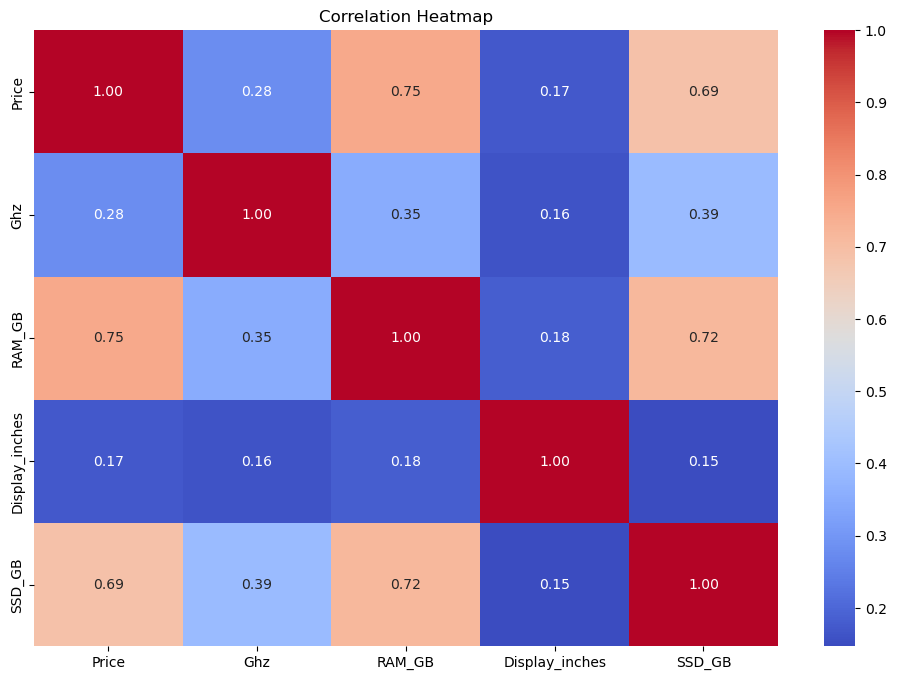

In [66]:
plt.figure(figsize=(12,8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# seperate X abd y

In [67]:
X = df.drop(columns=["Price"])
y = df["Price"]

In [68]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3924, 11)
y shape: (3924,)


# Train Test Split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Categorical columns - only columns actually present in X_train
categorical_cols = [
    'Brand',
    'RAM_Expandable',
    'RAM_TYPE',
    'GPU_Brand',
    'Processor_Family',
    'GPU_Type',
    'Laptop_Type'
]

# Numerical columns
numerical_cols = [
    'Ghz',
    'RAM_GB',
    'Display_inches',
    'SSD_GB'
]

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        sparse_output=False,
        drop='first',
        handle_unknown='ignore'
    ))
])

# Numerical preprocessing
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Combine both
preprocessor = ColumnTransformer([
    ('cat', categorical_transformer, categorical_cols),
    ('num', numerical_transformer, numerical_cols)
])

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Brand', 'RAM_Expandable', 'RAM_TYPE', 'GPU_Brand', 'Processor_Family', 'GPU_Type', 'Laptop_Type']
Numerical columns: ['Ghz', 'RAM_GB', 'Display_inches', 'SSD_GB']


In [74]:
print("X_train columns:")
print(X_train.columns.tolist())

X_train columns:
['Brand', 'RAM_Expandable', 'RAM_TYPE', 'Ghz', 'GPU_Brand', 'RAM_GB', 'Display_inches', 'GPU_Type', 'SSD_GB', 'Processor_Family', 'Laptop_Type']


# Linear Regression

In [75]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression")
print("------------------")
print("MAE :", mean_absolute_error(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("R2 Score:", r2_score(y_test, y_pred_linear))

Linear Regression
------------------
MAE : 16908.720062494045
RMSE: 28238.94139951685
R2 Score: 0.7344800364452098


C:\Users\miile\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# KNN

In [77]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

# Train
knn_model.fit(X_train, y_train)

# Prediction
y_pred_knn = knn_model.predict(X_test)

# Evaluation
print("KNN Regressor")
print("-------------")
print("MAE :", mean_absolute_error(y_test, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2 Score:", r2_score(y_test, y_pred_knn))

C:\Users\miile\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


KNN Regressor
-------------
MAE : 16903.830318471337
RMSE: 30918.634576845558
R2 Score: 0.6816968267004084


# Decision Tree

In [78]:
from sklearn.tree import DecisionTreeRegressor

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        max_depth=15,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Regressor")
print("-----------------------")
print("MAE :", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print("R2 Score:", r2_score(y_test, y_pred_tree))

Decision Tree Regressor
-----------------------
MAE : 15872.678487711566
RMSE: 30553.062673836546
R2 Score: 0.6891793550199685


C:\Users\miile\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Random Forest

In [82]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print("------------------")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest
------------------
MAE : 14770.433759754525
RMSE: 27821.98599243005
R2 Score: 0.7422630940251307


C:\Users\miile\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [81]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting")
print("------------------")
print("MAE :", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2 Score:", r2_score(y_test, y_pred_gb))

Gradient Boosting
------------------
MAE : 15196.737888382786
RMSE: 27102.41646276249
R2 Score: 0.7554225659224009


C:\Users\miile\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [83]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regressor",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_knn),
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_knn)),
        np.sqrt(mean_squared_error(y_test, y_pred_tree)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_knn),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

# Sort by R2 Score - highest is best
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,15196.737888,27102.416463,0.755423
1,Random Forest,14770.433760,27821.985992,0.742263
2,Linear Regression,16908.720062,28238.941400,0.734480
3,Decision Tree,15872.678488,30553.062674,0.689179
4,KNN Regressor,16903.830318,30918.634577,0.681697


In [85]:
pipe = gb_model

In [86]:
import pickle

pickle.dump(df, open('df.pkl', 'wb'))
pickle.dump(pipe, open('pipe.pkl', 'wb'))

print("Best model saved successfully!")
print("Model: Gradient Boosting")

Best model saved successfully!
Model: Gradient Boosting
